<a href="https://colab.research.google.com/github/mzaib1012/CSI-Based-ML-Object-Classification-Pipeline/blob/main/notebooks/csi_object_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# --- 1. Simulate Radio Environment & Generate CSI Data ---
np.random.seed(42)
torch.manual_seed(42)

num_samples_per_class = 400
num_classes = 3  # 0: Empty Space, 1: Object A, 2: Object B
antennas_tx, antennas_rx = 10, 10

X_data = []
y_data = []

for label in range(num_classes):
    for _ in range(num_samples_per_class):
        # Base Rayleigh fading channel (Background Noise)
        base_channel = (np.random.randn(antennas_tx, antennas_rx) +
                        1j * np.random.randn(antennas_tx, antennas_rx)) * 0.5

        # Inject deterministic Multipath Signature based on the physical object
        if label == 1:
            # Object A: Creates a central blocking/scattering cluster (amplitude drop)
            base_channel[3:7, 3:7] *= 0.15
        elif label == 2:
            # Object B: Creates a diagonal scattering path with unique phase shifts
            np.fill_diagonal(base_channel, base_channel.diagonal() * 2.5)

        # Extract Amplitude and Phase features (2 channels, like an RGB image)
        amplitude = np.abs(base_channel)
        phase = np.angle(base_channel)

        # Stack as a (2, 10, 10) tensor feature map
        csi_matrix = np.stack([amplitude, phase], axis=0)
        X_data.append(csi_matrix)
        y_data.append(label)

X = np.array(X_data, dtype=np.float32)
y = np.array(y_data, dtype=np.int64)

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Convert to PyTorch DataLoaders
train_dataset = TensorDataset(torch.tensor(X_train), torch.tensor(y_train))
test_dataset = TensorDataset(torch.tensor(X_test), torch.tensor(y_test))

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Dataset generated. Feature map shape: {X.shape[1:]}")
print(f"Training samples: {len(X_train)}, Testing samples: {len(X_test)}")

Dataset generated. Feature map shape: (2, 10, 10)
Training samples: 960, Testing samples: 240


In [3]:
# --- 2. Define the CSI-CNN Classifier ---
class CSICNN(nn.Module):
    def __init__(self, num_classes=3):
        super(CSICNN, self).__init__()
        # Input shape: (batch_size, 2, 10, 10)
        self.conv_block = nn.Sequential(
            nn.Conv2d(in_channels=2, out_channels=16, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU()
        )
        # Spatial dimensions remain 10x10 due to padding=1. Flattened size: 32 * 10 * 10 = 3200
        self.fc_block = nn.Sequential(
            nn.Linear(32 * 10 * 10, 128),
            nn.ReLU(),
            nn.Dropout(0.3),  # Prevents overfitting on synthetic patterns
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.conv_block(x)
        x = x.view(x.size(0), -1) # Flatten
        x = self.fc_block(x)
        return x

# Instantiate model, loss function, and optimizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CSICNN(num_classes=3).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(f"CNN model compiled successfully and pushed to: {device}")

CNN model compiled successfully and pushed to: cuda


Starting pipeline training...
Epoch 01/15 | Loss: 0.8619 | Test Accuracy: 95.42%
Epoch 02/15 | Loss: 0.1667 | Test Accuracy: 99.17%
Epoch 03/15 | Loss: 0.0388 | Test Accuracy: 99.58%
Epoch 04/15 | Loss: 0.0233 | Test Accuracy: 99.58%
Epoch 05/15 | Loss: 0.0087 | Test Accuracy: 100.00%
Epoch 06/15 | Loss: 0.0044 | Test Accuracy: 99.58%
Epoch 07/15 | Loss: 0.0072 | Test Accuracy: 99.58%
Epoch 08/15 | Loss: 0.0041 | Test Accuracy: 99.17%
Epoch 09/15 | Loss: 0.0024 | Test Accuracy: 99.58%
Epoch 10/15 | Loss: 0.0025 | Test Accuracy: 99.17%
Epoch 11/15 | Loss: 0.0013 | Test Accuracy: 99.58%
Epoch 12/15 | Loss: 0.0007 | Test Accuracy: 99.58%
Epoch 13/15 | Loss: 0.0008 | Test Accuracy: 99.17%
Epoch 14/15 | Loss: 0.0008 | Test Accuracy: 99.17%
Epoch 15/15 | Loss: 0.0007 | Test Accuracy: 99.17%


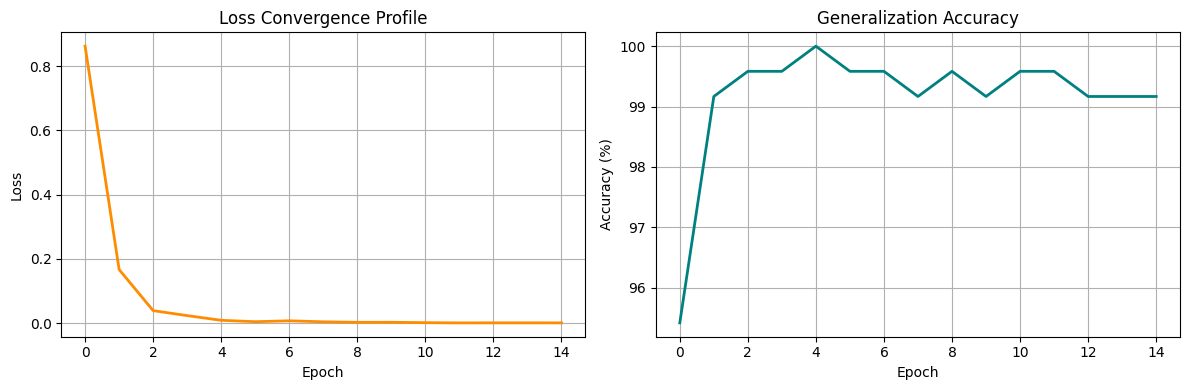

In [4]:
# --- 3. Training Loop & Validation ---
epochs = 15
train_losses, test_accs = [], []

print("Starting pipeline training...")
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_loss)

    # Evaluate Test Set Accuracy
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    test_accuracy = (correct / total) * 100
    test_accs.append(test_accuracy)
    print(f"Epoch {epoch+1:02d}/{epochs} | Loss: {epoch_loss:.4f} | Test Accuracy: {test_accuracy:.2f}%")

# --- 4. Plot & Save Performance Profiles ---
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss', color='darkorange', lw=2)
plt.title('Loss Convergence Profile')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(test_accs, label='Test Accuracy', color='teal', lw=2)
plt.title('Generalization Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.grid(True)

plt.tight_layout()
plt.savefig('csi_pipeline_performance.png', dpi=300)
plt.show()